In [39]:
from graphs import env_graph
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

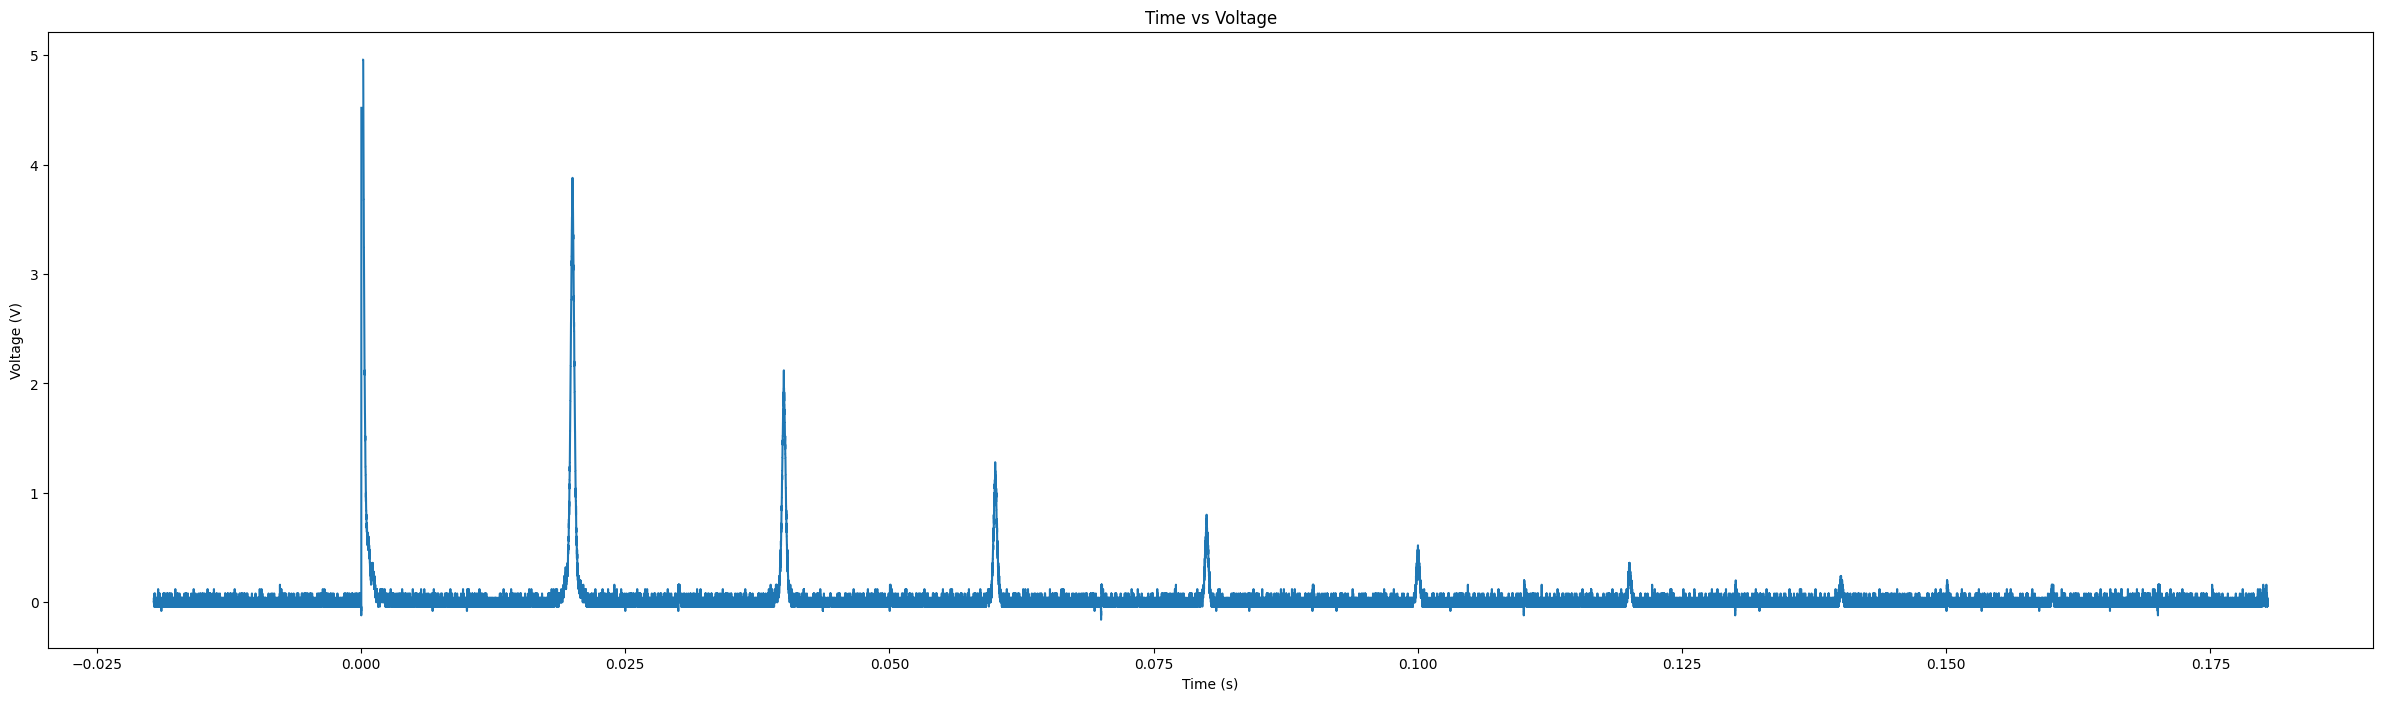

In [24]:
file = "Data/T2/MG(10ms).csv"
env_graph(file)

In [ ]:
def exp_model(t, M0, T2, phi):
   return M0 * np.exp(-t/T2) + phi


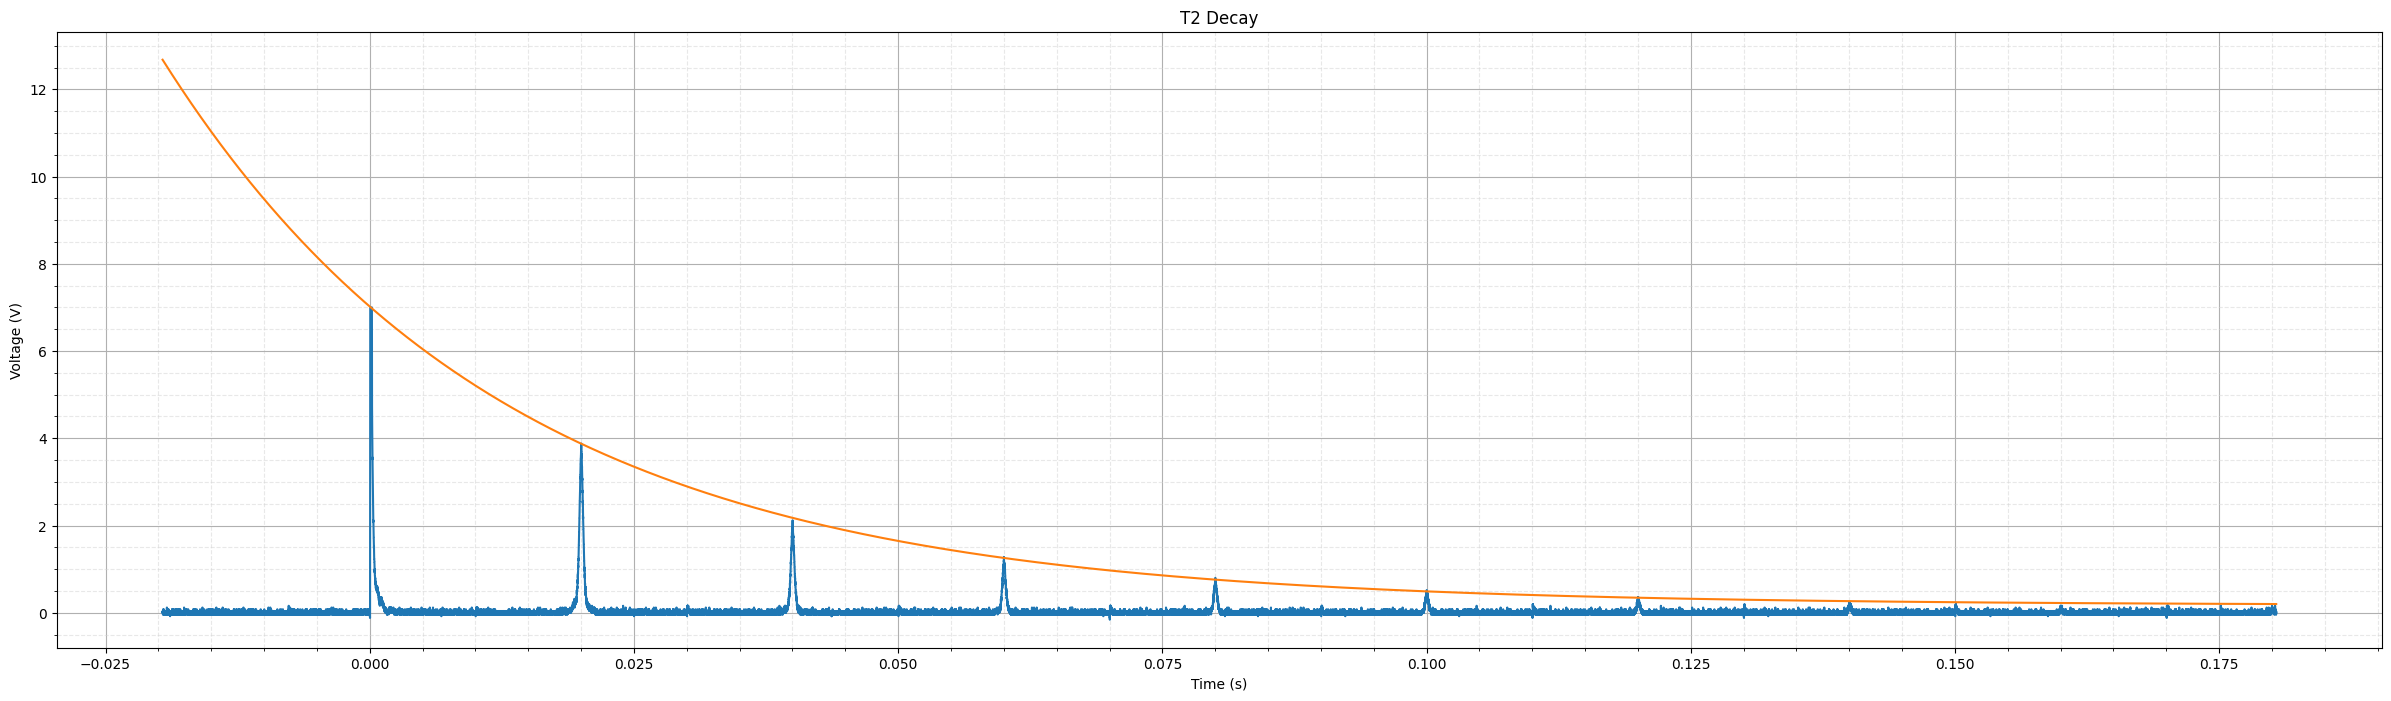

T2: 0.03254156472937532s ± 0.0004868670980417623s


In [47]:
file = "Data/T2/MG(10ms).csv"
df = pd.read_csv(f"{file}", skiprows=20)

time = df["TIME"]
env = df["CH1"]

# DC Offset
env = env - np.median(env)

env = np.clip(env, None, 7)

dt = time[1] - time[0]

peaks, _ = find_peaks(env, height=0.2, distance = 0.01/dt)

peak_time = time[peaks]
peak_env = env[peaks]

popt, pcov = curve_fit(exp_model, peak_time, peak_env)

perr = np.sqrt(np.diag(pcov))


fig = plt.figure(figsize=(30,8))
plt.plot(time, env)
plt.plot(time, exp_model(time, *popt))
plt.grid()
plt.minorticks_on()
plt.grid(visible=True, which='minor', color='lightgray', linestyle='--', alpha=0.5)
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("T2 Decay")
fig.savefig(f"T2.png", dpi=300, bbox_inches="tight")

plt.show()

print(f'T2: {popt[1]}s ± {perr[1]}s')